# 06 - Inverse Design with Ensemble Sampling

This notebook builds the optional **inverse design** solution for the Boom Challenge.

The forward prediction task answers:

```text
impact parameters -> ejecta outcomes
```

The inverse design task asks the opposite question:

```text
desired ejecta outcomes -> find impact parameters
```

The challenge requires proposing **20 impact scenarios** satisfying:

```text
96 <= P80 <= 101
R95 <= 175
```

The input parameters must also stay inside the bounds provided in `inverse_design/constraints.json`.

This notebook uses the final forward model as a fast surrogate simulator and adds an ensemble-based uncertainty check to reduce false positives.


## Strategy

Because the forward model is not perfect around the feasible zone, the inverse design strategy is conservative:

1. Generate many candidate scenarios inside the allowed input bounds.
2. Add extra candidates around known feasible / near-feasible training regimes.
3. Predict outcomes using the final forward model.
4. Build an ensemble for the key constraints (`P80`, `R95`) to estimate prediction stability.
5. Filter candidates using both the final model and ensemble mean predictions.
6. Rank candidates by constraint satisfaction, uncertainty, safety margin, low `R95`, and low `energy`.
7. Select 20 diversified candidates.

The output file must contain exactly:

```text
submission_id, energy, angle_rad, coupling, strength, porosity, gravity, atmosphere, shape_factor
```


In [1]:
from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
INVERSE_DIR = PROJECT_ROOT / "data" / "raw" / "inverse_design"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SUBMISSIONS_DIR = OUTPUTS_DIR / "submissions"
MODELS_DIR = OUTPUTS_DIR / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

for path in [SUBMISSIONS_DIR, MODELS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data directory:", FORWARD_DIR)
print("Inverse design directory:", INVERSE_DIR)
print("Submissions directory:", SUBMISSIONS_DIR)
print("Models directory:", MODELS_DIR)


Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Inverse design directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/inverse_design
Submissions directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions
Models directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/models


## 1. Load Data and Constraints

The constraints file defines:

- the required target region for the design task;
- the legal bounds for generated input scenarios.


In [2]:
input_cols = [
    "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor"
]

target_cols = [
    "P80", "fines_frac", "oversize_frac",
    "R95", "R50_fines", "R50_oversize"
]

fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

raw_train = pd.read_csv(FORWARD_DIR / "train.csv")[input_cols]
raw_test = pd.read_csv(FORWARD_DIR / "test.csv")[input_cols]
y = pd.read_csv(FORWARD_DIR / "train_labels.csv")[target_cols]

constraints_path = INVERSE_DIR / "constraints.json"
if not constraints_path.exists():
    constraints_path = PROJECT_ROOT / "constraints.json"

with open(constraints_path, "r") as f:
    constraints_data = json.load(f)

output_constraints = constraints_data["constraints"]
input_bounds = constraints_data["input_bounds"]

p80_min = output_constraints["p80_min"]
p80_max = output_constraints["p80_max"]
r95_max = output_constraints["r95_max"]
p80_center = (p80_min + p80_max) / 2

print("Raw train:", raw_train.shape)
print("Raw test:", raw_test.shape)
print("Targets:", y.shape)
print("Constraints path:", constraints_path)

print("Output constraints:")
display(pd.DataFrame([output_constraints]))

print("Input bounds:")
display(pd.DataFrame(input_bounds).T)


Raw train: (2930, 8)
Raw test: (492, 8)
Targets: (2930, 6)
Constraints path: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/inverse_design/constraints.json
Output constraints:


,p80_min,p80_max,r95_max
0,96.0,101.0,175.0


Input bounds:


,min,max
energy,0.500000,5.000000
angle_rad,0.261799,1.570796
coupling,0.200000,1.700000
strength,0.400000,4.200000
porosity,0.000000,0.330000
gravity,1.020000,10.470000
atmosphere,0.000000,1.000000
shape_factor,0.700000,1.500000


## 2. Feature Engineering

These features must match the forward modeling notebooks. They are proxy variables inspired by physics, not exact physical equations.


In [3]:
def add_physics_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    eps = 1e-9

    # 1. Energy transfer features
    X["effective_energy"] = X["energy"] * X["coupling"]
    X["log_energy"] = np.log1p(X["energy"])
    X["log_effective_energy"] = np.log1p(X["effective_energy"])

    # 2. Angle decomposition
    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["tan_angle"] = np.tan(X["angle_rad"])
    X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
    X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]
    X["vertical_horizontal_ratio"] = X["vertical_energy"] / (X["horizontal_energy"] + eps)

    # 3. Material / fragmentation proxies
    X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
    X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
    X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
    X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)
    X["coupling_porosity"] = X["coupling"] * X["porosity"]
    X["coupling_atmosphere"] = X["coupling"] * X["atmosphere"]
    X["porosity_strength"] = X["porosity"] * X["strength"]

    # 4. Gravity and range proxies
    X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
    X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
    X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
    X["vertical_energy_per_gravity"] = X["vertical_energy"] / (X["gravity"] + eps)

    # 5. Atmosphere and drag proxies
    X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
    X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
    X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
    X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

    # 6. Pi-like scaling proxies inspired by dimensional analysis
    X["pi_gravity_proxy"] = (X["gravity"] * X["coupling"]) / (X["energy"] + eps)
    X["pi_strength_proxy"] = X["strength"] / (X["gravity"] * X["coupling"] + eps)
    X["pi_atmosphere_proxy"] = X["atmosphere"] / (X["gravity"] * X["coupling"] + eps)

    # 7. Regime indicators observed during EDA
    X["porosity_regime"] = (X["porosity"] > 0.15).astype(int)
    X["strength_regime"] = (X["strength"] > 2.6).astype(int)
    X["angle_regime"] = (X["angle_rad"] > 0.95).astype(int)
    X["atm_regime"] = (X["atmosphere"] > 0.30).astype(int)
    X["regime_combo"] = (
        X["porosity_regime"] * 8
        + X["strength_regime"] * 4
        + X["angle_regime"] * 2
        + X["atm_regime"]
    )

    # 8. Additional cross-regime proxies
    X["scaled_energy"] = X["effective_energy"] / (X["strength"] * np.sqrt(X["gravity"]) + eps)
    X["fragility"] = X["porosity"] / (X["strength"] + eps)
    X["range_proxy"] = (X["effective_energy"] * (X["cos_angle"] ** 2)) / (X["gravity"] * X["strength"] + eps)
    X["energy_sin_angle"] = X["energy"] * X["sin_angle"]
    X["momentum_proxy"] = X["effective_energy"] * X["sin_angle"]

    # Risk-controlled atmosphere ratio
    X["coupling_per_atm_clipped"] = X["coupling"] / (X["atmosphere"] + 1e-3)
    X["log_coupling_per_atm"] = np.log1p(X["coupling_per_atm_clipped"])
    X["retention_factor"] = X["atmosphere"] * X["drag_proxy"] / (X["energy"] + eps)

    return X

X_fe_train = add_physics_features(raw_train)
X_fe_test = add_physics_features(raw_test)

print("X_fe_train:", X_fe_train.shape)
print("X_fe_test:", X_fe_test.shape)


X_fe_train: (2930, 48)
X_fe_test: (492, 48)


## 3. Feature Sets and Model Builders

The inverse design filtering is mainly driven by `P80` and `R95`, but we keep the full forward model to inspect all predicted outcomes.


In [4]:
raw_features = input_cols.copy()

core_physics_features = raw_features + [
    "effective_energy", "log_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "tan_angle",
    "horizontal_energy", "vertical_energy", "vertical_horizontal_ratio",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity", "atmosphere_shape_energy", "atmosphere_per_gravity",
]

extended_physics_features = core_physics_features + [
    "pi_gravity_proxy", "pi_strength_proxy", "pi_atmosphere_proxy",
    "scaled_energy", "fragility", "range_proxy",
    "energy_sin_angle", "momentum_proxy",
    "coupling_per_atm_clipped", "log_coupling_per_atm", "retention_factor",
]

extended_plus_regimes_features = extended_physics_features + [
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo"
]

fragmentation_features = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength",
    "drag_proxy", "atmosphere_shape_energy",
    "pi_strength_proxy", "pi_atmosphere_proxy", "scaled_energy", "fragility",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

distance_features = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity", "atmosphere_shape_energy", "atmosphere_per_gravity",
    "pi_gravity_proxy", "pi_atmosphere_proxy", "scaled_energy", "range_proxy",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]


def clean_feature_list(features, X):
    seen = set()
    out = []
    for f in features:
        if f in X.columns and f not in seen:
            out.append(f)
            seen.add(f)
    return out

raw_features = clean_feature_list(raw_features, X_fe_train)
core_physics_features = clean_feature_list(core_physics_features, X_fe_train)
extended_physics_features = clean_feature_list(extended_physics_features, X_fe_train)
extended_plus_regimes_features = clean_feature_list(extended_plus_regimes_features, X_fe_train)
fragmentation_features = clean_feature_list(fragmentation_features, X_fe_train)
distance_features = clean_feature_list(distance_features, X_fe_train)
full_features = X_fe_train.columns.tolist()

feature_sets = {
    "raw": raw_features,
    "core_physics": core_physics_features,
    "extended_physics": extended_physics_features,
    "extended_plus_regimes": extended_plus_regimes_features,
    "fragmentation": fragmentation_features,
    "distance": distance_features,
    "full_features": full_features,
}


def get_features_for_feature_set(feature_set_name: str, target: str):
    if feature_set_name == "target_family_specific":
        return fragmentation_features if target in fragmentation_targets else distance_features
    return feature_sets[feature_set_name]


def build_extratrees(random_state=42):
    return ExtraTreesRegressor(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
    )

try:
    from catboost import CatBoostRegressor
    def build_catboost(random_state=42):
        return CatBoostRegressor(
            iterations=1200,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=5.0,
            loss_function="RMSE",
            random_seed=random_state,
            verbose=False,
        )
    CATBOOST_AVAILABLE = True
except Exception as e:
    print("CatBoost unavailable:", e)
    CATBOOST_AVAILABLE = False

try:
    from xgboost import XGBRegressor
    def build_xgb(random_state=42):
        return XGBRegressor(
            n_estimators=900,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=2,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.05,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=random_state,
            n_jobs=-1,
        )
    XGB_AVAILABLE = True
except Exception as e:
    print("XGBoost unavailable:", e)
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    def build_lgbm(random_state=42):
        return LGBMRegressor(
            n_estimators=1200,
            learning_rate=0.025,
            num_leaves=31,
            min_child_samples=20,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.05,
            reg_lambda=2.0,
            random_state=random_state,
            n_jobs=-1,
            verbosity=-1,
        )
    LGBM_AVAILABLE = True
except Exception as e:
    print("LightGBM unavailable:", e)
    LGBM_AVAILABLE = False


## 4. Final Forward Model Class

The final forward model is a single pipeline object, but internally it uses a specialized model per target.

This class definition is included here so that `joblib.load()` can reload the model saved by notebook 05.


In [5]:
def clip_predictions(preds, target):
    preds = np.asarray(preds).copy()
    if target in ["fines_frac", "oversize_frac"]:
        return np.clip(preds, 0, 1)
    return np.clip(preds, 0, None)

model_builders = {"ExtraTrees": build_extratrees}
if CATBOOST_AVAILABLE:
    model_builders["CatBoost"] = build_catboost

class TargetSpecificForwardModel:
    def __init__(self, target_configs, feature_engineering_func, feature_selector, random_state=42):
        self.target_configs = target_configs
        self.feature_engineering_func = feature_engineering_func
        self.feature_selector = feature_selector
        self.random_state = random_state
        self.models_ = {}
        self.feature_columns_ = None

    def fit(self, X_raw: pd.DataFrame, y_df: pd.DataFrame):
        X_fe = self.feature_engineering_func(X_raw)
        self.feature_columns_ = X_fe.columns.tolist()

        for i, target in enumerate(y_df.columns):
            config = self.target_configs[target]
            model_name = config["model"]
            feature_set_name = config["feature_set"]
            model_builder = model_builders[model_name]
            features = self.feature_selector(feature_set_name, target)

            model = model_builder(random_state=self.random_state + i)
            model.fit(X_fe[features], y_df[target])

            self.models_[target] = {
                "model": model,
                "model_name": model_name,
                "feature_set": feature_set_name,
                "features": features,
            }

        return self

    def predict(self, X_raw: pd.DataFrame) -> pd.DataFrame:
        X_fe = self.feature_engineering_func(X_raw)
        preds = pd.DataFrame(index=X_raw.index)

        for target, info in self.models_.items():
            model = info["model"]
            features = info["features"]
            pred = model.predict(X_fe[features])
            preds[target] = clip_predictions(pred, target)

        return preds[target_cols]

    def describe(self):
        rows = []
        for target, info in self.models_.items():
            rows.append({
                "target": target,
                "model": info["model_name"],
                "feature_set": info["feature_set"],
                "n_features": len(info["features"]),
            })
        return pd.DataFrame(rows)


## 5. Load or Rebuild Final Forward Model

The notebook first tries to load the saved model from notebook 05.
If loading fails, it rebuilds the same target-specific pipeline from raw training data.


In [6]:
target_configs = {
    "P80": {"model": "ExtraTrees", "feature_set": "target_family_specific"},
    "fines_frac": {"model": "ExtraTrees", "feature_set": "target_family_specific"},
    "oversize_frac": {
        "model": "CatBoost" if CATBOOST_AVAILABLE else "ExtraTrees",
        "feature_set": "extended_plus_regimes" if CATBOOST_AVAILABLE else "target_family_specific",
    },
    "R95": {"model": "ExtraTrees", "feature_set": "extended_plus_regimes"},
    "R50_fines": {"model": "ExtraTrees", "feature_set": "extended_plus_regimes"},
    "R50_oversize": {"model": "ExtraTrees", "feature_set": "extended_plus_regimes"},
}

model_path = MODELS_DIR / "final_target_specific_forward_model.joblib"

try:
    final_forward_model = joblib.load(model_path)
    print("Loaded final forward model from:", model_path)
except Exception as e:
    print("Could not load saved final model. Rebuilding it from training data.")
    print("Reason:", e)
    final_forward_model = TargetSpecificForwardModel(
        target_configs=target_configs,
        feature_engineering_func=add_physics_features,
        feature_selector=get_features_for_feature_set,
        random_state=42,
    )
    final_forward_model.fit(raw_train, y)

print("Final model description:")
display(final_forward_model.describe())


Loaded final forward model from: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/models/final_target_specific_forward_model.joblib
Final model description:


,target,model,feature_set,n_features
0,P80,ExtraTrees,target_family_specific,34
1,fines_frac,ExtraTrees,target_family_specific,34
2,oversize_frac,CatBoost,extended_plus_regimes,48
3,R95,ExtraTrees,extended_plus_regimes,48
4,R50_fines,ExtraTrees,extended_plus_regimes,48
5,R50_oversize,ExtraTrees,extended_plus_regimes,48


## 6. Train Constraint Ensemble for P80 and R95

For inverse design, the key constraints are `P80` and `R95`. We build a small ensemble of models for these two targets to estimate prediction stability.

A candidate is safer when:

- the ensemble mean satisfies the constraints;
- the ensemble standard deviation is low;
- the final forward model also predicts it as feasible.


In [8]:
ensemble_specs = []

# Strong baseline models from previous notebooks
ensemble_specs.append(("ExtraTrees_family", build_extratrees, "target_family_specific"))
ensemble_specs.append(("ExtraTrees_regimes", build_extratrees, "extended_plus_regimes"))

if CATBOOST_AVAILABLE:
    ensemble_specs.append(("CatBoost_family", build_catboost, "target_family_specific"))
    ensemble_specs.append(("CatBoost_regimes", build_catboost, "extended_plus_regimes"))

if XGB_AVAILABLE:
    ensemble_specs.append(("XGBoost_family", build_xgb, "target_family_specific"))
    ensemble_specs.append(("XGBoost_regimes", build_xgb, "extended_plus_regimes"))

if LGBM_AVAILABLE:
    ensemble_specs.append(("LightGBM_family", build_lgbm, "target_family_specific"))
    ensemble_specs.append(("LightGBM_regimes", build_lgbm, "extended_plus_regimes"))

print("Ensemble models:")
for name, _, fset in ensemble_specs:
    print("-", name, "|", fset)

constraint_targets = ["P80", "R95"]
ensemble_models = {target: [] for target in constraint_targets}

for target in constraint_targets:
    print(f"Training ensemble models for {target}...")
    for i, (name, builder, feature_set_name) in enumerate(ensemble_specs):
        features = get_features_for_feature_set(feature_set_name, target)
        model = builder(random_state=1000 + i)
        model.fit(X_fe_train[features], y[target])
        ensemble_models[target].append({
            "name": name,
            "model": model,
            "features": features,
            "feature_set": feature_set_name,
        })
        print("  trained", name)


Ensemble models:
- ExtraTrees_family | target_family_specific
- ExtraTrees_regimes | extended_plus_regimes
- CatBoost_family | target_family_specific
- CatBoost_regimes | extended_plus_regimes
- XGBoost_family | target_family_specific
- XGBoost_regimes | extended_plus_regimes
- LightGBM_family | target_family_specific
- LightGBM_regimes | extended_plus_regimes
Training ensemble models for P80...
  trained ExtraTrees_family
  trained ExtraTrees_regimes
  trained CatBoost_family
  trained CatBoost_regimes
  trained XGBoost_family
  trained XGBoost_regimes
  trained LightGBM_family
  trained LightGBM_regimes
Training ensemble models for R95...
  trained ExtraTrees_family
  trained ExtraTrees_regimes
  trained CatBoost_family
  trained CatBoost_regimes
  trained XGBoost_family
  trained XGBoost_regimes
  trained LightGBM_family
  trained LightGBM_regimes


## 7. Candidate Generation

We generate candidates using two complementary methods:

1. **Global Latin Hypercube / Monte Carlo sampling** inside the full allowed bounds.
2. **Jittered sampling around feasible and near-feasible training examples**, because the true feasible zone is rare.

The second method is important because only a small fraction of the training set satisfies the inverse-design constraints.


In [9]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

FAST_MODE = False

if FAST_MODE:
    N_GLOBAL = 50_000
    N_LOCAL = 30_000
else:
    N_GLOBAL = 250_000
    N_LOCAL = 150_000

print("N_GLOBAL:", N_GLOBAL)
print("N_LOCAL:", N_LOCAL)


def bounds_arrays(input_bounds, input_cols):
    lower = np.array([input_bounds[c]["min"] for c in input_cols], dtype=float)
    upper = np.array([input_bounds[c]["max"] for c in input_cols], dtype=float)
    return lower, upper

lower_bounds, upper_bounds = bounds_arrays(input_bounds, input_cols)


def sample_latin_hypercube(n_samples: int, random_state: int = 42) -> pd.DataFrame:
    try:
        from scipy.stats import qmc
        sampler = qmc.LatinHypercube(d=len(input_cols), seed=random_state)
        sample = sampler.random(n_samples)
        values = qmc.scale(sample, lower_bounds, upper_bounds)
    except Exception as e:
        print("Latin Hypercube unavailable. Falling back to uniform sampling.")
        print("Reason:", e)
        values = rng.uniform(lower_bounds, upper_bounds, size=(n_samples, len(input_cols)))
    return pd.DataFrame(values, columns=input_cols)


def feasibility_mask(df_targets):
    return (df_targets["P80"].between(p80_min, p80_max)) & (df_targets["R95"] <= r95_max)


def near_feasible_mask(df_targets):
    # Wider region used to identify useful local regimes
    return (df_targets["P80"].between(80, 120)) & (df_targets["R95"] <= 250)

true_feasible_train = feasibility_mask(y)
near_feasible_train = near_feasible_mask(y)

print("True feasible rows in train:", int(true_feasible_train.sum()))
print("Near feasible rows in train:", int(near_feasible_train.sum()))

def sample_local_jitter(n_samples: int, random_state: int = 42) -> pd.DataFrame:
    rng_local = np.random.default_rng(random_state)

    seed_pool = raw_train.loc[near_feasible_train].copy()
    if len(seed_pool) == 0:
        seed_pool = raw_train.copy()

    seed_indices = rng_local.integers(0, len(seed_pool), size=n_samples)
    base = seed_pool.iloc[seed_indices].reset_index(drop=True)

    # Jitter scale based on train standard deviation and allowed bounds.
    train_std = raw_train[input_cols].std().values
    bound_range = upper_bounds - lower_bounds
    jitter_scale = np.minimum(0.12 * train_std, 0.04 * bound_range)

    noise = rng_local.normal(loc=0.0, scale=jitter_scale, size=(n_samples, len(input_cols)))
    values = base[input_cols].values + noise
    values = np.clip(values, lower_bounds, upper_bounds)

    return pd.DataFrame(values, columns=input_cols)

global_candidates = sample_latin_hypercube(N_GLOBAL, random_state=RANDOM_STATE)
local_candidates = sample_local_jitter(N_LOCAL, random_state=RANDOM_STATE + 1)

candidates = pd.concat([global_candidates, local_candidates], ignore_index=True)

# Add original train near-feasible rows as anchors, keeping only input columns.
candidates = pd.concat([candidates, raw_train.loc[near_feasible_train, input_cols]], ignore_index=True)

# Remove exact duplicates after rounding for safety.
candidates = candidates.round(10).drop_duplicates().reset_index(drop=True)

print("Candidate pool shape:", candidates.shape)
display(candidates.head())


N_GLOBAL: 250000
N_LOCAL: 150000
True feasible rows in train: 35
Near feasible rows in train: 372
Candidate pool shape: (400372, 8)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor
0,1.103058,0.561280,1.549809,3.487444,0.059998,8.312264,0.706425,1.120205
1,2.263782,1.434627,0.520692,3.945036,0.173942,8.934419,0.316022,1.055721
2,2.639704,0.487413,1.167003,0.734208,0.061570,8.837178,0.174052,0.866612
3,0.933408,0.501423,1.437749,2.856532,0.040596,1.031654,0.339009,1.019043
4,0.519902,0.676629,1.566539,1.525132,0.260828,9.427571,0.259475,0.921371


## 8. Predict Candidate Outcomes

We predict candidates with:

- the final forward model;
- the constraint ensemble for `P80` and `R95`.

Then we compute uncertainty/stability diagnostics.


In [10]:
def predict_constraint_ensemble(candidates_raw: pd.DataFrame) -> pd.DataFrame:
    X_fe = add_physics_features(candidates_raw)
    out = pd.DataFrame(index=candidates_raw.index)

    for target in constraint_targets:
        model_preds = []
        for info in ensemble_models[target]:
            pred = info["model"].predict(X_fe[info["features"]])
            pred = clip_predictions(pred, target)
            model_preds.append(pred)
            out[f"{target}_{info['name']}"] = pred

        pred_matrix = np.vstack(model_preds).T
        out[f"{target}_ens_mean"] = pred_matrix.mean(axis=1)
        out[f"{target}_ens_std"] = pred_matrix.std(axis=1)
        out[f"{target}_ens_min"] = pred_matrix.min(axis=1)
        out[f"{target}_ens_max"] = pred_matrix.max(axis=1)

    return out

print("Predicting candidates with final forward model...")
final_preds = final_forward_model.predict(candidates)

print("Predicting candidates with constraint ensemble...")
ensemble_preds = predict_constraint_ensemble(candidates)

candidate_results = pd.concat([candidates, final_preds.add_prefix("final_"), ensemble_preds], axis=1)

print("Candidate results shape:", candidate_results.shape)
display(candidate_results.head())


Predicting candidates with final forward model...
Predicting candidates with constraint ensemble...
Candidate results shape: (400372, 38)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor,final_P80,final_fines_frac,final_oversize_frac,final_R95,final_R50_fines,final_R50_oversize,P80_ExtraTrees_family,P80_ExtraTrees_regimes,P80_CatBoost_family,P80_CatBoost_regimes,P80_XGBoost_family,P80_XGBoost_regimes,P80_LightGBM_family,P80_LightGBM_regimes,P80_ens_mean,P80_ens_std,P80_ens_min,P80_ens_max,R95_ExtraTrees_family,R95_ExtraTrees_regimes,R95_CatBoost_family,R95_CatBoost_regimes,R95_XGBoost_family,R95_XGBoost_regimes,R95_LightGBM_family,R95_LightGBM_regimes,R95_ens_mean,R95_ens_std,R95_ens_min,R95_ens_max
0,1.103058,0.561280,1.549809,3.487444,0.059998,8.312264,0.706425,1.120205,208.544224,0.010393,0.688679,70.724493,104.637048,38.083966,209.541463,203.853981,214.347589,209.694396,244.112579,241.870514,244.383329,242.178641,226.247811,17.110390,203.853981,244.383329,69.441011,68.600293,42.575900,60.144416,58.813869,59.738068,13.014887,17.853423,48.772734,20.747639,13.014887,69.441011
1,2.263782,1.434627,0.520692,3.945036,0.173942,8.934419,0.316022,1.055721,239.229137,0.001810,0.872242,47.486793,79.463387,28.023621,239.538944,240.773607,268.321666,263.029094,291.456024,296.347382,299.511153,299.993151,274.871377,23.897355,239.538944,299.993151,48.708161,49.009525,38.491469,49.932296,62.934711,80.599129,34.040181,40.942071,50.582193,14.021254,34.040181,80.599129
2,2.639704,0.487413,1.167003,0.734208,0.061570,8.837178,0.174052,0.866612,153.904572,0.101511,0.296832,124.016761,130.414003,53.903953,154.061771,151.588506,131.107394,128.497555,95.505753,93.202881,90.423315,89.684122,116.758912,25.936147,89.684122,154.061771,113.786740,124.222769,192.161191,176.288407,209.289078,178.006683,148.594546,125.228976,158.447299,33.145145,113.786740,209.289078
3,0.933408,0.501423,1.437749,2.856532,0.040596,1.031654,0.339009,1.019043,216.602552,0.007334,0.758096,343.941861,448.741565,181.549599,218.492132,208.156600,226.829404,215.098094,254.730835,252.126038,253.292951,255.302289,235.503543,18.984585,208.156600,255.302289,355.062616,345.430320,344.178259,407.268552,424.317749,385.289520,377.146847,385.118945,377.976601,27.012358,344.178259,424.317749
4,0.519902,0.676629,1.566539,1.525132,0.260828,9.427571,0.259475,0.921371,182.522480,0.020156,0.687935,58.551159,74.919884,30.403604,183.184924,177.540934,202.331537,203.945392,243.415558,237.085449,243.871760,243.256546,216.829013,26.454051,177.540934,243.871760,53.052676,59.634875,63.100204,78.526875,62.247406,59.149551,32.649293,38.263580,55.828057,13.639654,32.649293,78.526875


## 9. Constraint Filtering and Scoring

We use several filters:

- **final model feasibility**: final forward model predicts constraints satisfied;
- **ensemble mean feasibility**: ensemble average predicts constraints satisfied;
- **safety margin**: stricter thresholds to reduce false positives;
- **uncertainty**: low disagreement between ensemble models.

The score rewards candidates that are close to the center of the P80 band, have low R95, low uncertainty, and lower impact energy.


In [11]:
def constraint_violation(p80, r95, p80_min=p80_min, p80_max=p80_max, r95_max=r95_max):
    return (
        np.maximum(p80_min - p80, 0)
        + np.maximum(p80 - p80_max, 0)
        + np.maximum(r95 - r95_max, 0)
    )

candidate_results["final_feasible"] = (
    candidate_results["final_P80"].between(p80_min, p80_max)
    & (candidate_results["final_R95"] <= r95_max)
)

candidate_results["ens_feasible"] = (
    candidate_results["P80_ens_mean"].between(p80_min, p80_max)
    & (candidate_results["R95_ens_mean"] <= r95_max)
)

# Conservative margin for safer candidates.
candidate_results["safe_feasible"] = (
    candidate_results["P80_ens_mean"].between(97.0, 100.0)
    & (candidate_results["R95_ens_mean"] <= 160.0)
    & (candidate_results["final_P80"].between(96.0, 101.0))
    & (candidate_results["final_R95"] <= 175.0)
)

candidate_results["ens_constraint_violation"] = constraint_violation(
    candidate_results["P80_ens_mean"],
    candidate_results["R95_ens_mean"],
)

candidate_results["final_constraint_violation"] = constraint_violation(
    candidate_results["final_P80"],
    candidate_results["final_R95"],
)

# Lower score is better.
# The weights are heuristic and can be adjusted after inspecting candidate availability.
candidate_results["design_score"] = (
    8.0 * np.abs(candidate_results["P80_ens_mean"] - p80_center)
    + 0.04 * candidate_results["R95_ens_mean"]
    + 1.5 * candidate_results["P80_ens_std"]
    + 0.04 * candidate_results["R95_ens_std"]
    + 0.20 * candidate_results["energy"]
    + 15.0 * candidate_results["ens_constraint_violation"]
    + 15.0 * candidate_results["final_constraint_violation"]
)

summary = {
    "total_candidates": len(candidate_results),
    "final_feasible": int(candidate_results["final_feasible"].sum()),
    "ensemble_feasible": int(candidate_results["ens_feasible"].sum()),
    "safe_feasible": int(candidate_results["safe_feasible"].sum()),
}
summary_df = pd.DataFrame([summary])
display(summary_df)

candidate_pool = candidate_results[
    candidate_results["final_feasible"] & candidate_results["ens_feasible"]
].copy()

safe_pool = candidate_results[candidate_results["safe_feasible"]].copy()

print("Candidate pool:", candidate_pool.shape)
print("Safe pool:", safe_pool.shape)

display(candidate_pool.sort_values("design_score").head(10))


,total_candidates,final_feasible,ensemble_feasible,safe_feasible
0,400372,16294,16398,8377


Candidate pool: (12607, 44)
Safe pool: (8377, 44)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor,final_P80,final_fines_frac,final_oversize_frac,final_R95,final_R50_fines,final_R50_oversize,P80_ExtraTrees_family,P80_ExtraTrees_regimes,P80_CatBoost_family,P80_CatBoost_regimes,P80_XGBoost_family,P80_XGBoost_regimes,P80_LightGBM_family,P80_LightGBM_regimes,P80_ens_mean,P80_ens_std,P80_ens_min,P80_ens_max,R95_ExtraTrees_family,R95_ExtraTrees_regimes,R95_CatBoost_family,R95_CatBoost_regimes,R95_XGBoost_family,R95_XGBoost_regimes,R95_LightGBM_family,R95_LightGBM_regimes,R95_ens_mean,R95_ens_std,R95_ens_min,R95_ens_max,final_feasible,ens_feasible,safe_feasible,ens_constraint_violation,final_constraint_violation,design_score
281506,3.416691,0.784376,1.289377,1.892615,0.308421,9.861554,0.486195,1.321979,98.139903,0.095237,0.070884,86.592805,81.897310,37.264893,97.955118,98.136411,98.511066,98.026610,98.959793,98.932312,98.516665,98.899820,98.492224,0.389112,97.955118,98.959793,85.534724,87.082336,81.315724,85.577557,93.574913,88.822227,88.515601,84.883030,86.913264,3.349563,81.315724,93.574913,True,True,True,0.0,0.0,4.939725
394986,3.801488,0.567512,0.757391,1.385881,0.294003,10.179310,0.839499,0.832437,99.075405,0.079425,0.064659,74.806389,72.547138,31.481105,98.514339,98.560923,97.978788,98.407702,97.882523,97.932083,99.319454,99.167034,98.470356,0.512020,97.882523,99.319454,75.005754,74.203698,80.464459,79.141923,77.671082,83.101456,70.914273,75.433745,76.992049,3.632380,70.914273,83.101456,True,True,True,0.0,0.0,4.990458
322606,3.217315,0.742617,1.333629,1.811721,0.306086,10.455045,0.664532,0.916205,98.038523,0.095039,0.066172,89.890288,86.256122,39.213811,97.997170,98.583399,98.041263,98.808573,98.468315,98.692719,99.244739,98.429498,98.533209,0.379865,97.997170,99.244739,87.940196,91.585254,78.595402,87.395893,86.542168,84.776237,83.924809,84.496936,85.657112,3.520522,78.595402,91.585254,True,True,True,0.0,0.0,5.046041
344512,3.223864,0.625563,0.864345,1.346453,0.330000,9.989450,0.616066,1.024933,99.701490,0.081914,0.076078,77.821359,76.548422,34.694682,99.833900,99.130907,97.853357,98.208421,98.492271,98.088333,98.128746,98.117837,98.481722,0.625623,97.853357,99.833900,79.502793,77.325436,84.589988,77.668675,82.663376,81.344727,82.414974,72.334758,79.730591,3.653985,72.334758,84.589988,True,True,True,0.0,0.0,5.064818
391393,3.857398,0.636890,0.847146,1.632682,0.330000,10.030104,0.822272,1.166845,99.145625,0.080559,0.083974,76.643641,72.577342,34.484685,98.962234,99.113658,98.615458,99.036964,98.563988,98.448174,97.325681,98.307637,98.546724,0.535868,97.325681,99.113658,75.954197,75.324401,75.386544,75.557568,75.962784,80.362534,77.377862,74.679235,76.325641,1.690351,74.679235,80.362534,True,True,True,0.0,0.0,5.069715
347472,2.846707,0.590529,1.080326,1.378950,0.282806,9.901995,0.683393,1.159860,97.934175,0.089252,0.056652,86.231628,83.240889,38.084762,98.584476,98.002966,99.579080,99.006447,98.644821,98.223167,98.197147,97.627520,98.483203,0.572645,97.627520,99.579080,86.315679,86.056448,85.072183,84.568150,87.411835,86.435539,89.466544,86.639293,86.495709,1.398957,84.568150,89.466544,True,True,True,0.0,0.0,5.078469
370960,3.749049,0.550259,1.370949,2.176426,0.311560,10.174361,0.486952,1.093322,99.149815,0.094621,0.074337,80.715215,76.952077,32.875689,99.235551,99.450981,98.091731,98.691758,98.513283,98.442368,98.260659,97.360139,98.505809,0.613255,97.360139,99.450981,83.317752,81.571098,85.634742,88.214861,87.205368,86.425552,80.525861,78.316617,83.901481,3.302518,78.316617,88.214861,True,True,True,0.0,0.0,5.204321
378442,3.498206,0.827086,1.612882,2.358284,0.330000,10.292785,0.842021,1.279480,97.679989,0.106333,0.077445,87.433527,83.098412,37.612451,97.654025,98.502260,99.033267,97.800467,98.546043,98.485367,99.391433,98.763442,98.522038,0.542206,97.654025,99.391433,88.034082,87.263359,83.478022,63.554513,87.331314,80.753456,76.036174,76.820449,80.408921,7.735091,63.554513,88.034082,True,True,True,0.0,0.0,5.215017
390650,3.505443,0.716244,0.684151

## 10. Candidate Diversification

The final design submission should not contain 20 nearly identical scenarios. We apply a simple greedy diversification method in scaled input space.

The algorithm:

1. Sort candidates by `design_score`.
2. Select the best candidate.
3. Add the next candidate only if it is sufficiently far from already selected candidates.
4. If fewer than 20 are selected, gradually relax the distance threshold.


In [12]:
def greedy_diverse_selection(pool: pd.DataFrame, n_select: int = 20, min_distance: float = 0.12) -> pd.DataFrame:
    if len(pool) == 0:
        return pool.copy()

    pool_sorted = pool.sort_values("design_score").reset_index(drop=True)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(pool_sorted[input_cols])

    selected_indices = []

    for i in range(len(pool_sorted)):
        if len(selected_indices) == 0:
            selected_indices.append(i)
        else:
            distances = np.linalg.norm(X_scaled[i] - X_scaled[selected_indices], axis=1)
            if distances.min() >= min_distance:
                selected_indices.append(i)

        if len(selected_indices) >= n_select:
            break

    return pool_sorted.iloc[selected_indices].copy()

# Prefer safe pool. If not enough, use the wider feasible pool. If still not enough, use lowest-violation candidates.
if len(safe_pool) >= 20:
    selection_source = safe_pool
    source_name = "safe_pool"
elif len(candidate_pool) >= 20:
    selection_source = candidate_pool
    source_name = "candidate_pool"
else:
    selection_source = candidate_results.sort_values([
        "ens_constraint_violation", "final_constraint_violation", "design_score"
    ]).head(5000).copy()
    source_name = "lowest_violation_pool"

print("Selection source:", source_name, selection_source.shape)

selected_designs = pd.DataFrame()
for threshold in [0.18, 0.15, 0.12, 0.10, 0.08, 0.05, 0.0]:
    selected_designs = greedy_diverse_selection(selection_source, n_select=20, min_distance=threshold)
    print("threshold", threshold, "selected", len(selected_designs))
    if len(selected_designs) >= 20:
        break

selected_designs = selected_designs.head(20).reset_index(drop=True)

print("Selected designs:", selected_designs.shape)
display(selected_designs[input_cols + [
    "final_P80", "final_R95", "P80_ens_mean", "P80_ens_std", "R95_ens_mean", "R95_ens_std",
    "final_feasible", "ens_feasible", "safe_feasible", "design_score"
]])


Selection source: safe_pool (8377, 44)
threshold 0.18 selected 20
Selected designs: (20, 44)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor,final_P80,final_R95,P80_ens_mean,P80_ens_std,R95_ens_mean,R95_ens_std,final_feasible,ens_feasible,safe_feasible,design_score
0,3.416691,0.784376,1.289377,1.892615,0.308421,9.861554,0.486195,1.321979,98.139903,86.592805,98.492224,0.389112,86.913264,3.349563,True,True,True,4.939725
1,3.801488,0.567512,0.757391,1.385881,0.294003,10.179310,0.839499,0.832437,99.075405,74.806389,98.470356,0.512020,76.992049,3.632380,True,True,True,4.990458
2,3.217315,0.742617,1.333629,1.811721,0.306086,10.455045,0.664532,0.916205,98.038523,89.890288,98.533209,0.379865,85.657112,3.520522,True,True,True,5.046041
3,3.223864,0.625563,0.864345,1.346453,0.330000,9.989450,0.616066,1.024933,99.701490,77.821359,98.481722,0.625623,79.730591,3.653985,True,True,True,5.064818
4,3.857398,0.636890,0.847146,1.632682,0.330000,10.030104,0.822272,1.166845,99.145625,76.643641,98.546724,0.535868,76.325641,1.690351,True,True,True,5.069715
5,2.846707,0.590529,1.080326,1.378950,0.282806,9.901995,0.683393,1.159860,97.934175,86.231628,98.483203,0.572645,86.495709,1.398957,True,True,True,5.078469
6,3.749049,0.550259,1.370949,2.176426,0.311560,10.174361,0.486952,1.093322,99.149815,80.715215,98.505809,0.613255,83.901481,3.302518,True,True,True,5.204321
7,3.498206,0.827086,1.612882,2.358284,0.330000,10.292785,0.842021,1.279480,97.679989,87.433527,98.522038,0.542206,80.408921,7.735091,True,True,True,5.215017
8,3.505443,0.716244,0.684151,1.239082,0.323802,9.894324,0.634569,0.831822,99.252898,85.429977,98.505130,0.732001,81.498834,3.852092,True,True,True,5.254166
9,4.168967,0.623712,1.257758,2.192041,0.289462,10.149111,0.872075,0.852092,97.642974,82.149990,98.518304,0.617297,83.339285,1.901911,True,True,True,5.315816


## 11. Diagnostics

We inspect distributions of the selected candidates and compare them with the training data and the allowed input bounds.


In [13]:
# Save full candidate report for later analysis.
candidate_report_path = REPORTS_DIR / "inverse_design_candidate_pool.csv"
selected_report_path = REPORTS_DIR / "inverse_design_selected_designs_diagnostics.csv"

# To avoid very large files, save the top 20,000 candidates by score and all selected designs.
candidate_results.sort_values("design_score").head(20_000).to_csv(candidate_report_path, index=False)
selected_designs.to_csv(selected_report_path, index=False)

print("Saved candidate report to:", candidate_report_path)
print("Saved selected diagnostics to:", selected_report_path)

# Basic selected summary.
selected_summary = selected_designs[input_cols + [
    "final_P80", "final_R95", "final_fines_frac", "final_oversize_frac", "final_R50_fines", "final_R50_oversize",
    "P80_ens_mean", "P80_ens_std", "R95_ens_mean", "R95_ens_std", "design_score"
]].describe().T

display(selected_summary)

# Check bounds.
bounds_check = []
for col in input_cols:
    bounds_check.append({
        "feature": col,
        "selected_min": selected_designs[col].min(),
        "selected_max": selected_designs[col].max(),
        "allowed_min": input_bounds[col]["min"],
        "allowed_max": input_bounds[col]["max"],
        "inside_bounds": (
            selected_designs[col].min() >= input_bounds[col]["min"]
            and selected_designs[col].max() <= input_bounds[col]["max"]
        ),
    })

display(pd.DataFrame(bounds_check))


Saved candidate report to: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports/inverse_design_candidate_pool.csv
Saved selected diagnostics to: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports/inverse_design_selected_designs_diagnostics.csv


,count,mean,std,min,25%,50%,75%,max
energy,20.0,3.546114,0.389356,2.840497,3.310030,3.526453,3.798844,4.373093
angle_rad,20.0,0.657203,0.081555,0.511221,0.609381,0.638103,0.699206,0.827086
coupling,20.0,1.119531,0.308107,0.545276,0.845698,1.200407,1.342959,1.612882
strength,20.0,1.745456,0.391211,1.134742,1.370826,1.831997,2.000724,2.358284
porosity,20.0,0.306110,0.018763,0.276401,0.290982,0.307254,0.321950,0.330000
gravity,20.0,10.075164,0.180584,9.861554,9.938621,10.019520,10.175599,10.470000
atmosphere,20.0,0.645378,0.150832,0.420932,0.511929,0.626282,0.801673,0.872075
shape_factor,20.0,1.083071,0.179498,0.831822,0.944403,1.081487,1.246213,1.351928
final_P80,20.0,98.502666,0.723259,97.122506,97.934678,98.545099,99.146673,99.701490
final_R95,20.0,84.145284,5.056673,74.806389,81.791296,84.469128,86.321922,95.281971


,feature,selected_min,selected_max,allowed_min,allowed_max,inside_bounds
0,energy,2.840497,4.373093,0.500000,5.000000,True
1,angle_rad,0.511221,0.827086,0.261799,1.570796,True
2,coupling,0.545276,1.612882,0.200000,1.700000,True
3,strength,1.134742,2.358284,0.400000,4.200000,True
4,porosity,0.276401,0.330000,0.000000,0.330000,True
5,gravity,9.861554,10.470000,1.020000,10.470000,True
6,atmosphere,0.420932,0.872075,0.000000,1.000000,True
7,shape_factor,0.831822,1.351928,0.700000,1.500000,True


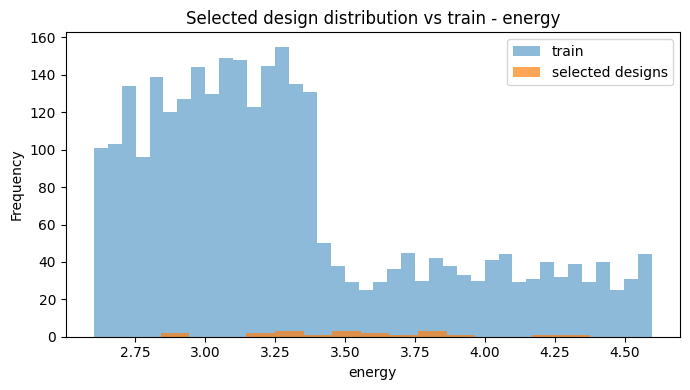

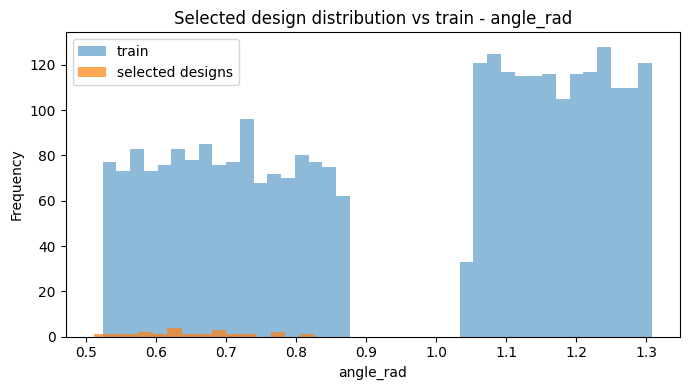

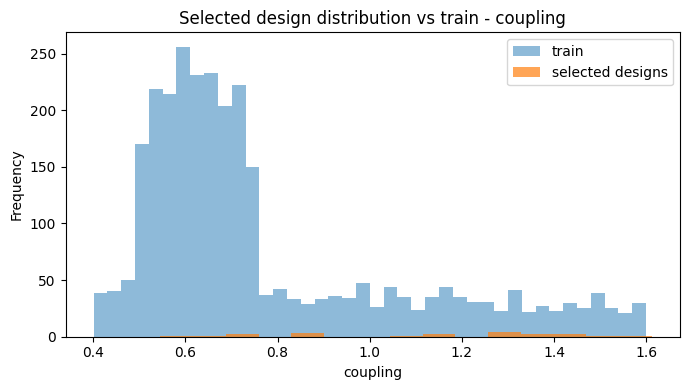

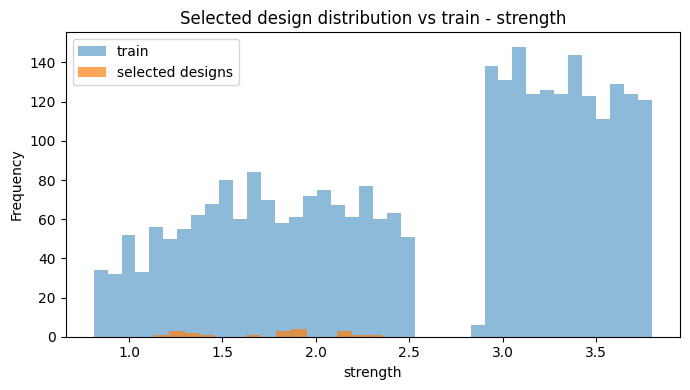

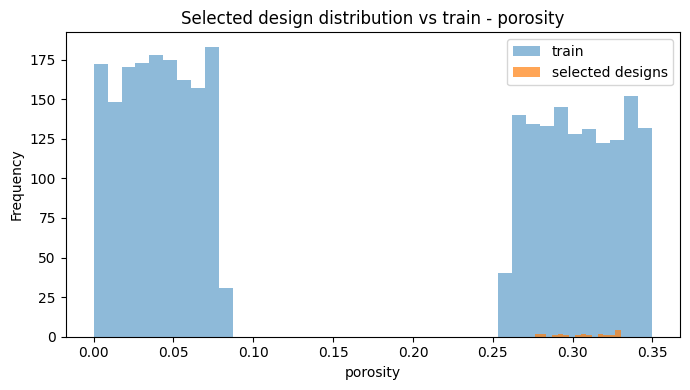

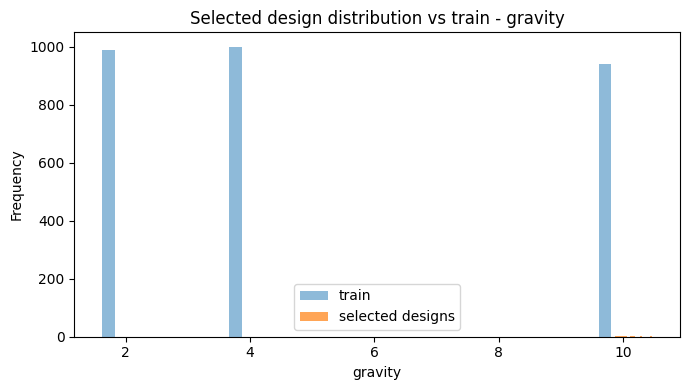

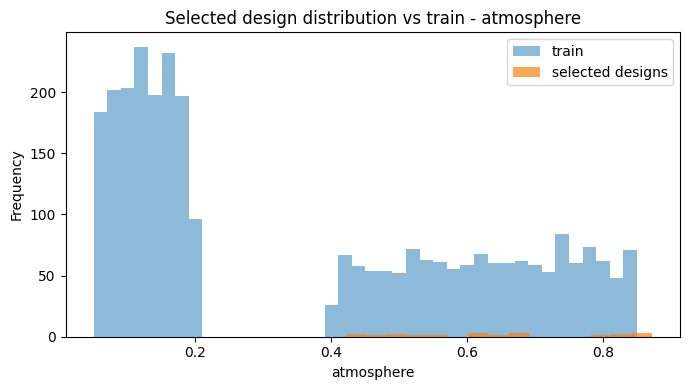

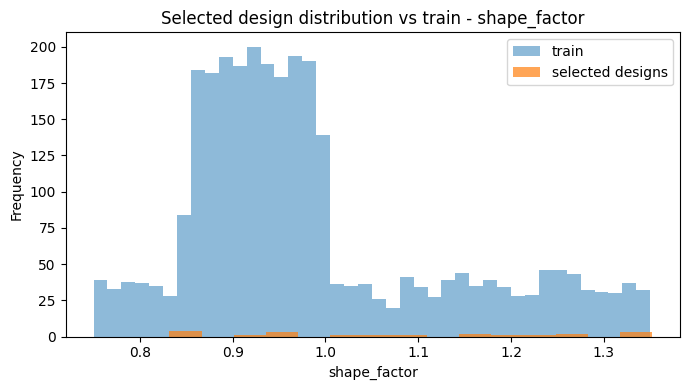

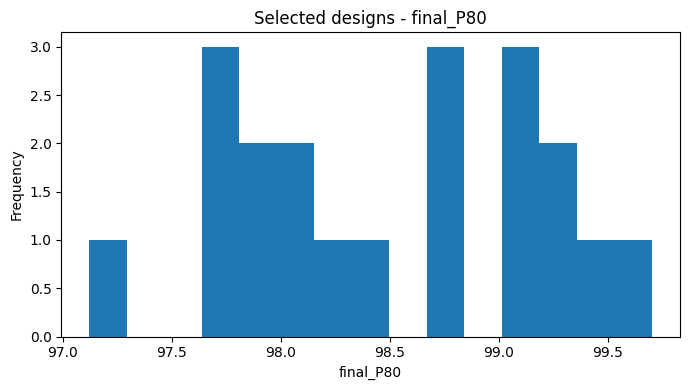

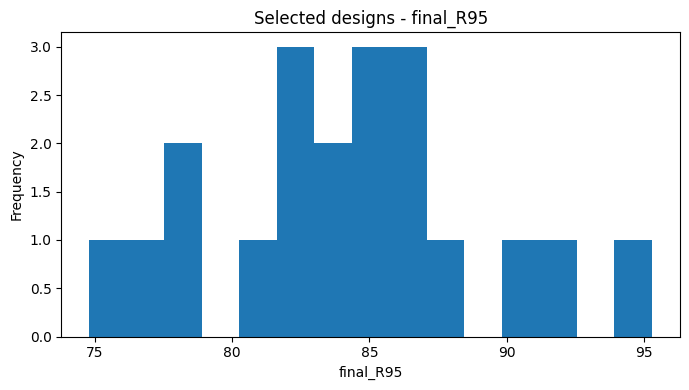

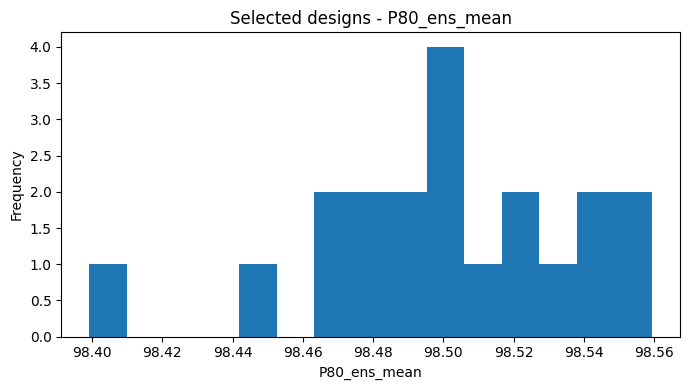

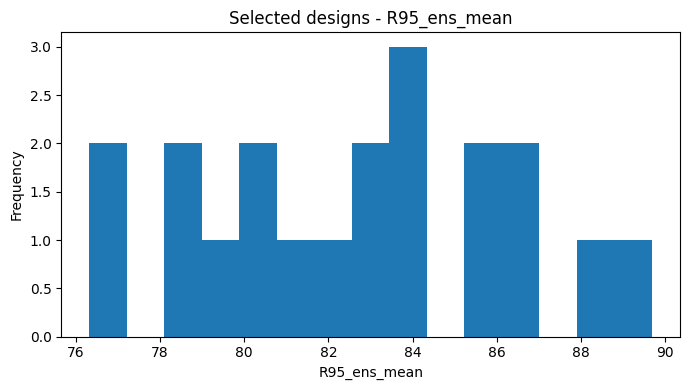

In [14]:
for col in input_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(raw_train[col], bins=40, alpha=0.5, label="train")
    plt.hist(selected_designs[col], bins=15, alpha=0.7, label="selected designs")
    plt.title(f"Selected design distribution vs train - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

for col in ["final_P80", "final_R95", "P80_ens_mean", "R95_ens_mean"]:
    plt.figure(figsize=(7, 4))
    plt.hist(selected_designs[col], bins=15)
    plt.title(f"Selected designs - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 12. Create `design_submission.csv`

The final inverse-design submission file must contain exactly 20 rows and the required columns:

```text
submission_id, energy, angle_rad, coupling, strength, porosity, gravity, atmosphere, shape_factor
```


In [15]:
design_submission = selected_designs[input_cols].copy()
design_submission.insert(0, "submission_id", np.arange(len(design_submission)))

expected_design_cols = ["submission_id"] + input_cols
design_submission = design_submission[expected_design_cols]

assert design_submission.shape == (20, 9), f"Expected shape (20, 9), got {design_submission.shape}"
assert design_submission.columns.tolist() == expected_design_cols

# Final bounds validation.
for col in input_cols:
    assert design_submission[col].between(input_bounds[col]["min"], input_bounds[col]["max"]).all(), f"{col} outside bounds"

design_submission_path = SUBMISSIONS_DIR / "design_submission.csv"
design_submission.to_csv(design_submission_path, index=False)

print("Saved inverse design submission to:", design_submission_path)
display(design_submission)


Saved inverse design submission to: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions/design_submission.csv


,submission_id,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor
0,0,3.416691,0.784376,1.289377,1.892615,0.308421,9.861554,0.486195,1.321979
1,1,3.801488,0.567512,0.757391,1.385881,0.294003,10.179310,0.839499,0.832437
2,2,3.217315,0.742617,1.333629,1.811721,0.306086,10.455045,0.664532,0.916205
3,3,3.223864,0.625563,0.864345,1.346453,0.330000,9.989450,0.616066,1.024933
4,4,3.857398,0.636890,0.847146,1.632682,0.330000,10.030104,0.822272,1.166845
5,5,2.846707,0.590529,1.080326,1.378950,0.282806,9.901995,0.683393,1.159860
6,6,3.749049,0.550259,1.370949,2.176426,0.311560,10.174361,0.486952,1.093322
7,7,3.498206,0.827086,1.612882,2.358284,0.330000,10.292785,0.842021,1.279480
8,8,3.505443,0.716244,0.684151,1.239082,0.323802,9.894324,0.634569,0.831822
9,9,4.168967,0.623712,1.257758,2.192041,0.289462,10.149111,0.872075,0.852092


## 13. Final Summary

This notebook creates the first inverse-design solution.

Main outputs:

```text
outputs/submissions/design_submission.csv
reports/inverse_design_candidate_pool.csv
reports/inverse_design_selected_designs_diagnostics.csv
```

Next steps after running:

1. Inspect whether at least 20 safe feasible candidates were found.
2. Review selected designs for diversity and physical plausibility.
3. If candidates are too close to the constraints, increase safety margins.
4. If not enough candidates are found, increase `N_GLOBAL` and `N_LOCAL`, or add an Optuna-based search step.
